In [1]:
# import all the E9 stuff
import logging
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path
import time
from scipy.linalg import eigh
from scipy.interpolate import interp1d
from collections import defaultdict

# User defined modules
E9path = Path("C:/", "Users", "ken92", "Documents", "Studies", "E5", "simulation", "E9_simulations")
if str(E9path) not in sys.path:
    sys.path.insert(1, str(E9path))
import E9_fn.E9_constants as E9c
import E9_fn.E9_atom as E9a
import E9_fn.E9_cooltrap as E9ct
import E9_fn.plane_wave_expansion.blochstate_class as bsc
# import E9_fn.polarizabilities_calculation as E9pol
# import E9_fn.datasets.transition_line_data as TLData
from E9_fn import util

# Logging
logpath = '' # '' if not logging to a file
loglevel = logging.INFO
logroot = logging.getLogger()
list(map(logroot.removeHandler, logroot.handlers))
list(map(logroot.removeFilter, logroot.filters))
logging.basicConfig(filename = logpath, level = loglevel)

c:\Users\ken92\Documents\Studies\E5\simulation\E9_simulations\.venv\Lib\site-packages\gftool\precision.py:16: UserWarning: No quad precision datatypes available!
Some functions might be less accurate.
  warnings.warn("No quad precision datatypes available!\n"


# Inputs

In [2]:
# species = "Rb87" # "Rb87", "K40"
species = "K40" # "Rb87", "K40"

# lattice parameters
V1064Er = 8            # 1064 lattice depth, in 1064 recoil energy
V532Er = 2             # 532 lattice depth, in 532 recoil energy
# Rb kHz to Er
# V1064Er = 20. / 2.02781   # 25.213063
# V532Er = 0. / 8.11125    # 35.517929
# K kHz to Er
# V1064Er = 39.5 / 4.4099   # 39.5
# V532Er = 0 / 17.6394    # 35.517929
n0nom = 0               # peak density
# The superlattice phase that determines the relative position between 1064 and 532 lattice
# 532 lattice is fixed at 0, so changing the phase by pi for 1064 restores the original lattice
phi12, phi23 = 0., 0.
# phi12, phi23 = -np.pi/10, np.pi/10   # split gamma QBTP along Mp-Mp4
# phi12, phi23 = np.pi/4, np.pi/5   # ABCD offset - use deep 532 lattice, e.g. 10 Er for both
# phi12, phi23 = np.pi*1/3, -np.pi*1/3    # decorated triangular lattice (2/3 also works)
# phi12, phi23 = -np.pi*1/3, 0    # stripe
ABoffset1064nom = 0     # max 0.011585 * V1064nom / 9 / np.sqrt(3) for Rb
B1_rel_int_1064 = 1     # relative intensity (field is sqrt of that) of 1064 B1
B1_rel_int_532  = 1     # relative intensity (field is sqrt of that) of 532 B1
B3_rel_int_1064 = 1     # relative intensity (field is sqrt of that) of 1064 B3
B3_rel_int_532  = 1     # relative intensity (field is sqrt of that) of 532 B3

# Basic simulation parameters
num = 5             # size of q-momentum space we consider: (-num, num) (usually 5)
k_center = (0, 0)
bandstart = 0       # starting from 0, inclusive
bandend = 7         # inclusive


In [3]:
# (most common) gamma, K, M, gamma
qverts_str = 'E9c.Gp/E9c.k_lw, E9c.Kp5/E9c.k_lw, E9c.Mp4/E9c.k_lw, E9c.Gp/E9c.k_lw'
x_ticklist = ['$\Gamma$', 'K', 'M', '$\Gamma$']

In [4]:
if species == "Rb87":
    all_units_dict = E9c.all_lat_unit_Rb87
    Er_1064 = E9c.E_r1064_Rb87
    Er_532 = E9c.E_r532_Rb87
elif species == "K40":
    all_units_dict = E9c.all_lat_unit_K40
    Er_1064 = E9c.E_r1064_K40
    Er_532 = E9c.E_r532_K40
else:
    raise ValueError("Unknown species: {}".format(species))
m_unit = all_units_dict["m_unit"]
l_unit = all_units_dict["l_unit"]
E_unit = all_units_dict["E_unit"]
f_unit = all_units_dict["f_unit"]
t_unit = all_units_dict["t_unit"]

V532nom = V532Er * Er_532 / E9c.hnobar / 1e3       # in kHz (i.e. V_SI / hbar / 1e3 / 2pi), assuming that polarizability is accounted for correctly
V1064nom = V1064Er * Er_1064  / E9c.hnobar / 1e3   # Note that setting this to 0 doesn't give you a proper band structure of 532 nm lattice, since you are now
                                # considering too many plane waves that don't actually contribute.
V532 = 2 * np.pi * V532nom * 1e3 / f_unit   # 2 * np.pi because I have f = E/hbar instead of E/h as normally defined
V1064 = 2 * np.pi * V1064nom * 1e3 / f_unit
ABoffset1064 = 2 * np.pi * ABoffset1064nom * 1e3 / f_unit
n0 = n0nom * l_unit**3

In [5]:
Exp_lib = {"species": species, "units_dict": all_units_dict
        , 'V532nom': V532nom, 'V1064nom': V1064nom, 'V532': V532, 'V1064': V1064
        , 'B1_rel_int_532': B1_rel_int_532, 'B1_rel_int_1064': B1_rel_int_1064 , 'B3_rel_int_532': B3_rel_int_532, 'B3_rel_int_1064': B3_rel_int_1064
        , 'n0nom': n0nom, 'n0': n0
        , 'ABoffset1064nom': ABoffset1064nom, 'ABoffset1064': ABoffset1064
        , 'phi12': phi12, 'phi23': phi23}

size = 2 * num + 1
bandnum = bandend - bandstart + 1 # number of bands interested in
qverts_arr = eval(qverts_str)

# Real space plots

# Finding Bloch states and band energies

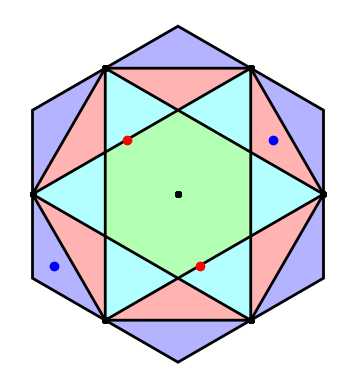

In [ ]:
# find non-interacting solution
fig_QBTP, ax_QBTP = plt.subplots(1, 1)#, figsize = (20, 16))
ax_QBTP.axis("off")
bsc.PlotBZSubplot(ax_QBTP,)
ax_QBTP.set_xlim(-2, 2)
ax_QBTP.set_ylim(-2.2, 2.2)

rK = 0.7
p1 = (rK * E9c.Kp + (1 - rK) * E9c.Kp6) / E9c.k_lw
p2 = p1 + E9c.G3G
ax_QBTP.scatter(*p1, color = "red")
ax_QBTP.scatter(*p2, color = "red")
p3 = p1 - E9c.G2G
p4 = p1 - E9c.G1G
ax_QBTP.scatter(*p3, color = "blue")
ax_QBTP.scatter(*p4, color = "blue")

thesis_fig_path = Path(r"C:\Users\ken92\Documents\Studies\E5\Theses\figures\geometric_probe")
band_struc_full_path = Path(thesis_fig_path, "BM_choice_QBTP.pdf")
# fig_QBTP.savefig(band_struc_full_path, facecolor = "none", dpi = 300, bbox_inches = 'tight')

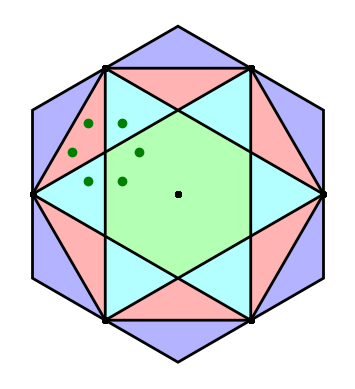

In [ ]:
# find non-interacting solution
fig_LBTP, ax_LBTP = plt.subplots(1, 1)#, figsize = (20, 16))
ax_LBTP.axis("off")
bsc.PlotBZSubplot(ax_LBTP)
ax_LBTP.set_xlim(-2, 2)
ax_LBTP.set_ylim(-2.2, 2.2)

rQ = 0.4
pK = E9c.Kp / E9c.k_lw
pi3 = np.pi / 3
for i in range(6):
    pt = pK + rQ * np.array([np.cos(i * pi3), np.sin(i * pi3)])
    ax_LBTP.scatter(*pt, color = "green")

band_struc_full_path = Path(thesis_fig_path, "BM_choice_LBTP.pdf")
# fig_LBTP.savefig(band_struc_full_path, facecolor = "none", dpi = 300, bbox_inches = 'tight')